# Phase 7: time-inhomogeneous exactness and the correlation term

structure

Computational record for `PHASE_7_TERM_STRUCTURE.md`. Verifies:

1.  **Static inheritance** — transition densities, expiry digitals, forward-start digitals, discrete range accruals, and the quantile term structure (q\_(t)=f(m(t)+,^{-1}())) against exact-skeleton Monte Carlo under deterministic ((t),(t)) curves;
2.  **Proportional-drift barrier class** (((t)=^2(t))) — reflection-principle laws in operational time (u=v(t)) against bridge-corrected Monte Carlo, and the parsimony corollary that two different volatility curves with equal integrated variance give *identical* barrier laws;
3.  **FK clock law under deterministic coefficient curves** (Crank–Nicolson) against Monte Carlo;
4.  **Term-structure bootstrap** of ((c,^{Q})) from correlation-digital quotes.

Seed `20260821`. Monte Carlo appears only as benchmark; all pricing-path quantities are deterministic.

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.special import ndtr

ROOT = Path.cwd().resolve()
if not (ROOT / "phase7_term_structure.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase7_term_structure.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase7_term_structure as p7

SEED = 20260821
rng = np.random.default_rng(SEED)
FIGURES = ROOT / "phase7_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}

## 1. Driver scenarios

Three deterministic coefficient scenarios: a constant-volatility baseline, a humped (log-normal-type) volatility curve, and an oscillating volatility curve. In Section 3 the oscillating curve is rescaled to match the humped curve’s integrated variance exactly, demonstrating the parsimony corollary.

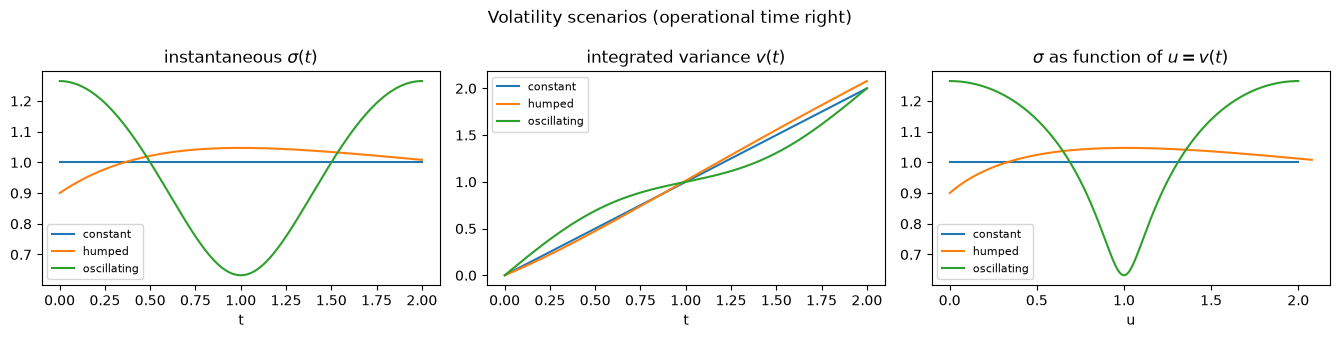

constant v(T) = 2.0
humped v(T) = 2.0781516559867748
oscillating v(T) = 2.0

In [2]:
T_HORIZON = 2.0
LAM, SCALE, RHO0 = 0.35, 1.1, -0.2

def vol_constant(t):
    return 1.0

def vol_humped(t):
    return 0.9 + 0.4 * t * math.exp(-t)

def vol_osc(t):
    return math.sqrt(1.0 + 0.6 * math.cos(2.0 * math.pi * t / T_HORIZON))

times = np.linspace(1e-3, T_HORIZON, 400)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
for name, volf in [("constant", vol_constant), ("humped", vol_humped), ("oscillating", vol_osc)]:
    v = p7.variance_curve(times, volatility=volf)
    axes[0].plot(times, [volf(t) for t in times], label=name)
    axes[1].plot(times, v, label=name)
    axes[2].plot(v, [volf(t) for t in times], label=name)
axes[0].set_title(r"instantaneous $\sigma(t)$")
axes[0].set_xlabel("t"); axes[0].legend(fontsize=8)
axes[1].set_title(r"integrated variance $v(t)$")
axes[1].set_xlabel("t"); axes[1].legend(fontsize=8)
axes[2].set_title(r"$\sigma$ as function of $u=v(t)$")
axes[2].set_xlabel("u"); axes[2].legend(fontsize=8)
fig.suptitle("Volatility scenarios (operational time right)")
fig.tight_layout()
fig.savefig(FIGURES / "phase7_vol_scenarios.png", dpi=150)
plt.show()

for name, volf in [("constant", vol_constant), ("humped", vol_humped), ("oscillating", vol_osc)]:
    print(name, "v(T) =", float(p7.variance_curve([T_HORIZON], volatility=volf)[0]))

## 2. Static inheritance: marginal/transition laws vs Monte Carlo

Exact-skeleton simulation of (X): no discretization bias in the driver. We check the transition density of () between (s=0.8) and (T=2.0) and the quantile term structure.

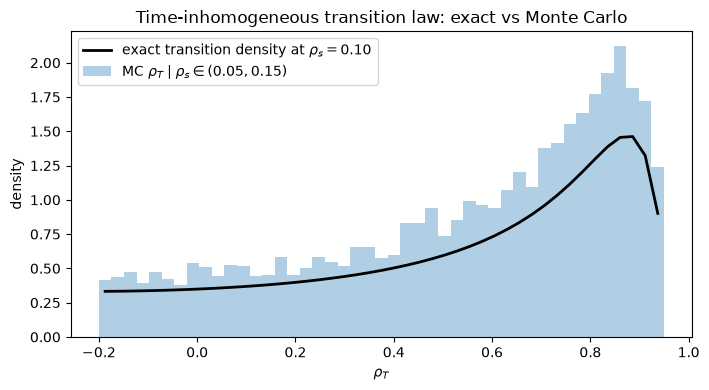

histogram mass 1.000000 vs exact window mass 0.737511
L1 diff (density scale): 0.22755

In [3]:
DRIFT = lambda t: 0.3 * (1.0 + 0.5 * math.exp(-t))
VOL = vol_humped
X0 = p7.x_from_rho(RHO0, scale=SCALE)

def simulate_paths(n_paths, n_steps, seed):
    local_rng = np.random.default_rng(seed)
    grid = np.linspace(0.0, T_HORIZON, n_steps + 1)
    X = np.full(n_paths, X0)
    paths = np.empty((n_steps + 1, n_paths))
    paths[0] = X
    for k in range(n_steps):
        t0, t1 = grid[k], grid[k + 1]
        m_dt = float(p7.mean_curve([t1], x0=0.0, drift=DRIFT)[0]) \
             - float(p7.mean_curve([t0], x0=0.0, drift=DRIFT)[0])
        v_dt = float(p7.variance_curve([t0, t1], volatility=VOL)[1] \
                     - p7.variance_curve([t0, t1], volatility=VOL)[0])
        X = X + m_dt + math.sqrt(v_dt) * local_rng.standard_normal(n_paths)
        paths[k + 1] = X
    return grid, paths

GRID, PATHS = simulate_paths(200000, 400, SEED)
RHO_PATHS = PATHS / np.sqrt(PATHS**2 + SCALE**2)

start_idx = int(np.searchsorted(GRID, 0.8))
rho_s = RHO_PATHS[start_idx]
rho_T = RHO_PATHS[-1]

# Transition density check: histogram of rho_T | rho_s in a slice.
mask = (rho_s > 0.05) & (rho_s < 0.15)
bin_edges = np.linspace(-0.2, 0.95, 46)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
hist, _ = np.histogram(rho_T[mask], bins=bin_edges, density=True)
mean_st, var_st = p7.interval_coefficients(GRID[start_idx], T_HORIZON, drift=DRIFT, volatility=VOL)
densities = np.array([
    p7.rho_transition_density_inhom(
        c, start=GRID[start_idx], maturity=T_HORIZON, rho_start=0.10,
        scale=SCALE, drift=DRIFT, volatility=VOL)
    for c in centers
])

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(centers, hist, width=np.diff(bin_edges), alpha=0.35,
       label=r"MC $\rho_T\mid\rho_s\in(0.05,0.15)$", color="C0")
ax.plot(centers, densities, "k-", lw=2,
        label="exact transition density at $\\rho_s=0.10$")
ax.set_xlabel(r"$\rho_T$"); ax.set_ylabel("density")
ax.set_title("Time-inhomogeneous transition law: exact vs Monte Carlo")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase7_transition_density.png", dpi=150)
plt.show()

# Numerical agreement: normalized histogram mass vs integrated density
from scipy.integrate import quad
mc_mass = float(np.sum(hist * np.diff(bin_edges)))
exact_mass = quad(
    lambda r: p7.rho_transition_density_inhom(
        r, start=GRID[start_idx], maturity=T_HORIZON, rho_start=0.10,
        scale=SCALE, drift=DRIFT, volatility=VOL),
    bin_edges[0], bin_edges[-1], epsabs=1e-12)[0]
print(f"histogram mass {mc_mass:.6f} vs exact window mass {exact_mass:.6f}")
print(f"L1 diff (density scale): {np.abs(hist - densities).mean():.5f}")

### Quantile term structure (q\_(t))

The exact correlation quantile curves are the model’s *term structure*: no competitor bounded-correlation model publishes closed quantile curves (Phase 7 literature audit).

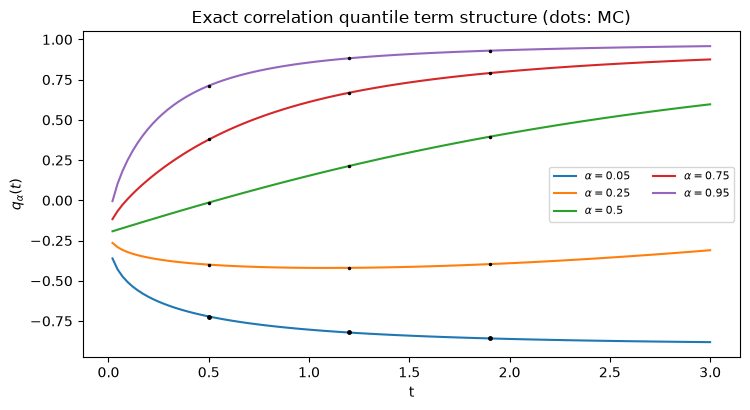

max |exact - MC| quantile error across checks: 0.0033

In [4]:
alphas = [0.05, 0.25, 0.5, 0.75, 0.95]
q_times = np.linspace(0.02, 3.0, 120)
Q = p7.quantile_term_structure(alphas, q_times, rho0=RHO0, scale=SCALE,
                               drift=DRIFT, volatility=VOL)

# MC empirical quantiles at three horizons (within simulated horizon)
check_times = [0.5, 1.2, 1.9]
idxs = [int(np.argmin(np.abs(q_times - ct))) for ct in check_times]
emp = {}
sim_grid, sim_paths = simulate_paths(400000, 600, SEED + 1)
sim_rho = sim_paths / np.sqrt(sim_paths**2 + SCALE**2)
for ct in check_times:
    j = int(np.searchsorted(sim_grid, ct))
    emp[ct] = np.quantile(sim_rho[j], alphas)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
for i, a in enumerate(alphas):
    ax.plot(q_times, Q[i], label=f"$\\alpha={a}$")
for ct in check_times:
    for i, a in enumerate(alphas):
        ax.plot(ct, emp[ct][i], "k.", ms=5 if i == 0 else 3, zorder=5)
ax.set_xlabel("t"); ax.set_ylabel(r"$q_\alpha(t)$")
ax.set_title("Exact correlation quantile term structure (dots: MC)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "phase7_quantile_term_structure.png", dpi=150)
plt.show()

max_err = max(abs(Q[i, idx] - emp[ct][i])
              for ct, idx in zip(check_times, idxs) for i in range(len(alphas)))
print(f"max |exact - MC| quantile error across checks: {max_err:.4f}")

### Expiry digitals and discrete range accruals vs Monte Carlo

In [5]:
rate = 0.04
digital_checks = []
for rho_star in (0.2, 0.45, 0.7):
    model_price = p7.digital_price_inhom(
        rho_star, maturity=T_HORIZON, rho0=RHO0, scale=SCALE,
        rate=rate, drift=DRIFT, volatility=VOL)
    mc_prob = float(np.mean(rho_T >= rho_star))
    se = math.sqrt(mc_prob * (1 - mc_prob) / rho_T.size)
    digital_checks.append((rho_star, model_price, math.exp(-rate*T_HORIZON)*mc_prob, se))

accrual_dates = (0.25, 0.5, 1.0, 1.5, 2.0)
accrual_model = p7.range_accrual_price_inhom(
    -0.4, 0.6, pay_dates=accrual_dates, rho0=RHO0, scale=SCALE,
    rate=rate, drift=DRIFT, volatility=VOL)
accrual_mc = 0.0
for d in accrual_dates:
    j = int(np.searchsorted(sim_grid, d))
    inside = (sim_rho[j] >= -0.4) & (sim_rho[j] <= 0.6)
    p = float(np.mean(inside)); se_d = math.sqrt(p*(1-p)/inside.size)
    per_date_model = p7.range_accrual_price_inhom(
        -0.4, 0.6, pay_dates=(d,), rho0=RHO0, scale=SCALE,
        rate=rate, drift=DRIFT, volatility=VOL)
    accrual_mc += math.exp(-rate*d) * p
    print(f"date {d}: model {per_date_model:.5f}  MC {math.exp(-rate*d)*p:.5f} (SE {math.exp(-rate*d)*se_d:.5f})")

print()
for rho_star, mp, mc_p, se in digital_checks:
    ok = abs(mp - mc_p) <= 2.5 * se
    print(f"digital rho*={rho_star}: model {mp:.5f}  MC {mc_p:.5f} (SE {se:.5f})  {'OK' if ok else 'FAIL'}")
print(f"range accrual: model {accrual_model:.5f}  MC {accrual_mc:.5f}")

date 0.25: model 0.74942  MC 0.74909 (SE 0.00067)
date 0.5: model 0.62675  MC 0.62632 (SE 0.00074)
date 1.0: model 0.46425  MC 0.46366 (SE 0.00076)
date 1.5: model 0.37267  MC 0.37152 (SE 0.00073)
date 2.0: model 0.31444  MC 0.31416 (SE 0.00069)

digital rho*=0.2: model 0.53280  MC 0.53390 (SE 0.00110)  OK
digital rho*=0.45: model 0.44901  MC 0.44998 (SE 0.00112)  OK
digital rho*=0.7: model 0.31893  MC 0.32006 (SE 0.00106)  OK
range accrual: model 2.52752  MC 2.52476

## 3. Proportional-drift barrier class: operational-time reduction

Under ((t)=^2(t)) the driver is (x_0+u+B_u) in operational time (u=v(t)); every Milestone-1 law holds with (tv(t)). We verify against bridge-corrected exact-skeleton MC for the humped and oscillating volatility curves, and demonstrate the parsimony corollary: equal (v(T)), different (()), identical barrier CDFs.

In [6]:
def simulate_hit_indicator(vol_func, n_paths, n_steps, seed, rho_star=0.55):
    # Exact-skeleton MC with Brownian-bridge crossing correction.
    local_rng = np.random.default_rng(seed)
    grid = np.linspace(0.0, T_HORIZON, n_steps + 1)
    x_star = p7.x_from_rho(rho_star, scale=SCALE)
    X = np.full(n_paths, X0)
    hit = X >= x_star
    prev = X.copy()
    for k in range(n_steps):
        t0, t1 = grid[k], grid[k + 1]
        mu_mid = LAM * vol_func(0.5 * (t0 + t1)) ** 2
        sig_mid = vol_func(0.5 * (t0 + t1))
        dt = t1 - t0
        X = X + mu_mid * dt + sig_mid * math.sqrt(dt) * local_rng.standard_normal(n_paths)
        d_prev = x_star - prev
        d_cur = x_star - X
        p_cross = np.exp(-2.0 * np.clip(d_prev, 0, None) * np.clip(d_cur, 0, None) / (sig_mid**2 * dt))
        newly = (~hit) & ((d_cur <= 0) | (local_rng.random(n_paths) < np.where(d_prev > 0, p_cross, 1.0)))
        hit |= newly
        prev = X.copy()
    return hit

rho_star_bar = 0.55
results = {}
# Parsimony demonstration: rescale the oscillating curve so that its
# integrated variance matches the humped curve's exactly.
v_h = float(p7.variance_curve([T_HORIZON], volatility=vol_humped)[0])
v_o = float(p7.variance_curve([T_HORIZON], volatility=vol_osc)[0])
scale_factor = math.sqrt(v_h / v_o)

def vol_osc_rescaled(t):
    return scale_factor * vol_osc(t)

for name, volf in [("humped", vol_humped), ("oscillating-rescaled", vol_osc_rescaled)]:
    model = p7.ProportionalDriftModel(lam=LAM, scale=SCALE, volatility=volf, rho0=RHO0)
    u_T = model.integrated_variance(T_HORIZON)
    exact = model.hitting_cdf(rho_star_bar, T_HORIZON)
    row = {"u_T": u_T, "exact": exact}
    for n_steps in (100, 400):
        est = float(np.mean(simulate_hit_indicator(volf, 200000, n_steps, SEED + 2)))
        row[f"MC({n_steps})"] = est
        row[f"SE({n_steps})"] = math.sqrt(est * (1 - est) / 200000)
    results[name] = row

for name, row in results.items():
    print(f"{name}: u(T)={row['u_T']:.4f}  exact={row['exact']:.5f}  "
          f"MC(100)={row['MC(100)']:.5f} ({row['SE(100)']:.5f})  "
          f"MC(400)={row['MC(400)']:.5f} ({row['SE(400)']:.5f})")
assert abs(results["humped"]["u_T"] - results["oscillating-rescaled"]["u_T"]) < 1e-10
assert abs(results["humped"]["exact"] - results["oscillating-rescaled"]["exact"]) < 1e-12
print("\nparsimony corollary: identical u(T), different sigma(.) => identical exact CDF")

humped: u(T)=2.0782  exact=0.67685  MC(100)=0.67608 (0.00105)  MC(400)=0.67628 (0.00105)
oscillating-rescaled: u(T)=2.0782  exact=0.67685  MC(100)=0.67766 (0.00105)  MC(400)=0.67605 (0.00105)

parsimony corollary: identical u(T), different sigma(.) => identical exact CDF

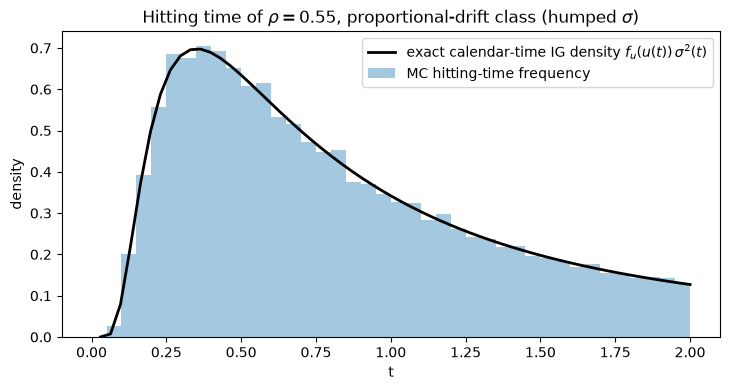

mean |MC - exact| over bins: 0.00956

In [7]:
# Hitting-time density in calendar time for the humped curve vs MC
rho_star_dens = 0.55
model_h = p7.ProportionalDriftModel(lam=LAM, scale=SCALE, volatility=vol_humped, rho0=RHO0)
dens_times = np.linspace(0.03, T_HORIZON, 60)
dens_vals = np.array([model_h.hitting_density(t, rho_star_dens) for t in dens_times])

# MC hitting times (first step where crossing registered), fine grid
n_paths, n_steps_fine = 200000, 800
local_rng = np.random.default_rng(SEED + 3)
grid_fine = np.linspace(0.0, T_HORIZON, n_steps_fine + 1)
x_star_d = p7.x_from_rho(rho_star_dens, scale=SCALE)
X = np.full(n_paths, X0)
tau = np.full(n_paths, np.nan)
prev = X.copy()
for k in range(n_steps_fine):
    t0, t1 = grid_fine[k], grid_fine[k + 1]
    sig_mid = vol_humped(0.5 * (t0 + t1))
    X = X + LAM * sig_mid**2 * (t1 - t0) + sig_mid * math.sqrt(t1 - t0) * local_rng.standard_normal(n_paths)
    crossed = (tau != tau) & ((X >= x_star_d) |
               (local_rng.random(n_paths) < np.exp(-2.0 * np.clip(x_star_d - prev, 0, None) * np.clip(x_star_d - X, 0, None) / (sig_mid**2 * (t1 - t0)))))
    tau[crossed] = t1
    prev = X.copy()
obs = tau[~np.isnan(tau)]
hist_t, edges_t = np.histogram(obs, bins=40, range=(0.0, T_HORIZON), density=False)
widths = np.diff(edges_t)
freq = hist_t / n_paths / widths

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.bar(0.5 * (edges_t[:-1] + edges_t[1:]), freq, width=widths, alpha=0.4, label="MC hitting-time frequency")
ax.plot(dens_times, dens_vals, "k-", lw=2, label="exact calendar-time IG density $f_u(u(t))\\,\\sigma^2(t)$")
ax.set_xlabel("t"); ax.set_ylabel("density")
ax.set_title(f"Hitting time of $\\rho={rho_star_dens}$, proportional-drift class (humped $\\sigma$)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase7_proportional_hitting_density.png", dpi=150)
plt.show()
l1 = np.abs(freq - np.array([model_h.hitting_density(0.5*(edges_t[i]+edges_t[i+1]), rho_star_dens) for i in range(len(hist_t))])).mean()
print(f"mean |MC - exact| over bins: {l1:.5f}")

## 4. FK clock characteristic function under deterministic curves

**A time-inhomogeneous Feynman–Kac pitfall (found and fixed in this phase).** The *backward* equation (\_t u = L_t u + if(x)u) — exact for constant coefficients, and the engine of Milestone 4 — is **not** satisfied by (u(t,x)=E_x\[e<sup>{i\_0</sup>t f(X_s)ds}\]) when the coefficients depend on calendar time: time-translation invariance fails. Counterexample (drift-only): (), ((t)=t) gives the true solution (e<sup>{i(xt+t</sup>3/6)}), which violates the equation whenever (’(t)). The correct primitive is the **forward** Feynman–Kac (Fokker–Planck with potential) equation for the tilted density (p):

\[ *t p=^2(t)p*{xx}-(t)p_x+if(x)p, p(0,x)=(x-x_0), ()=p(T,x),dx . \]

The module implements this with Crank–Nicolson stepping; the unit suite verifies it against (i) the Milestone-4 solver at constant coefficients, (ii) a closed-form Gaussian case with variable coefficients (linear potential), and (iii) second-order grid convergence. Below: agreement with Monte Carlo for the bounded correlation map under the humped-vol scenario.

In [8]:
xi_nodes = np.array([0.5, 1.5, 3.0])
phi_cn = np.array([
    p7.fk_characteristic_inhom(xi, maturity=T_HORIZON, x0=X0,
                               drift=DRIFT, volatility=VOL, scale=SCALE,
                               n_steps=600, n_grid=1200)
    for xi in xi_nodes
])
# MC: trapezoid integral of rho along exact skeletons
dts = np.diff(GRID)
A_mc = (0.5 * (RHO_PATHS[:-1] + RHO_PATHS[1:]) * dts[:, None]).sum(axis=0)
phi_mc = np.array([complex(np.mean(np.cos(xi * A_mc)), np.mean(np.sin(xi * A_mc))) for xi in xi_nodes])
se_re = np.array([np.std(np.cos(xi * A_mc)) / math.sqrt(A_mc.size) for xi in xi_nodes])
se_im = np.array([np.std(np.sin(xi * A_mc)) / math.sqrt(A_mc.size) for xi in xi_nodes])

for xi, cn, mc, sr, si in zip(xi_nodes, phi_cn, phi_mc, se_re, se_im):
    ok = abs(cn.real - mc.real) <= 4 * sr and abs(cn.imag - mc.imag) <= 4 * si
    print(f"xi={xi}: CN {cn.real:.5f}{cn.imag:+.5f}j | MC {mc.real:.5f}{mc.imag:+.5f}j "
          f"(SE {sr:.5f}/{si:.5f}) {'OK' if ok else 'FAIL'}")

# E[A_T]: PDE derivative vs exact marginal quadrature vs MC
h_fd = 2e-3
p_plus = p7.fk_characteristic_inhom(h_fd, maturity=T_HORIZON, x0=X0,
                                    drift=DRIFT, volatility=VOL, scale=SCALE,
                                    n_steps=600, n_grid=1200)
p_minus = p7.fk_characteristic_inhom(-h_fd, maturity=T_HORIZON, x0=X0,
                                     drift=DRIFT, volatility=VOL, scale=SCALE,
                                     n_steps=600, n_grid=1200)
ea_pde = ((p_plus - p_minus) / (2 * h_fd)).imag
from numpy.polynomial.hermite_e import hermegauss
g_nodes, g_weights = hermegauss(160)
gw = g_weights / math.sqrt(2.0 * math.pi)
def e_rho(t):
    m = float(p7.mean_curve([t], x0=X0, drift=DRIFT)[0])
    sd = math.sqrt(float(p7.variance_curve([t], volatility=VOL)[0]))
    xs = m + sd * g_nodes
    return float(gw @ (xs / np.sqrt(xs * xs + SCALE * SCALE)))
from scipy.integrate import quad as _quad
ea_exact = _quad(e_rho, 0.0, T_HORIZON, epsabs=1e-11, limit=200)[0]
print(f"\nE[A_T]: PDE {ea_pde:.5f} | exact quadrature {ea_exact:.5f} | MC {A_mc.mean():.5f}")

xi=0.5: CN 0.90874+0.06412j | MC 0.90937+0.06510j (SE 0.00019/0.00090) OK
xi=1.5: CN 0.34913+0.12803j | MC 0.35281+0.13074j (SE 0.00117/0.00171) OK
xi=3.0: CN -0.20463+0.02952j | MC -0.20264+0.03220j (SE 0.00154/0.00155) OK

E[A_T]: PDE 0.13452 | exact quadrature 0.13454 | MC 0.13648

## 5. Term-structure bootstrap of ((c,^{Q}))

Synthetic market: five correlation digitals quoted at ((T_j,\_j^\*)). The two-parameter proportional-class model is fitted by nonlinear least squares; recovery of the true parameters demonstrates identifiability, and the residual surface shows the fit geometry.

{
  "scale": 1.25,
  "lam": 0.3,
  "sum_squared_residuals": 0.0,
  "max_abs_residual": 0.0,
  "success": true
}

true (c, lam) = (1.25, 0.3); fitted = (1.250000, 0.300000)

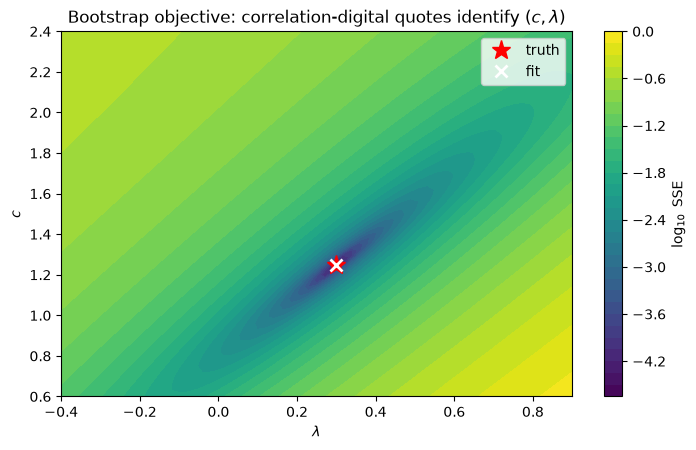

In [9]:
TRUE_SCALE, TRUE_LAM = 1.25, 0.30
boot_vol = vol_humped
true_model = p7.ProportionalDriftModel(lam=TRUE_LAM, scale=TRUE_SCALE,
                                       volatility=boot_vol, rho0=RHO0)
quotes = [(T, rs, true_model.digital_price(rs, maturity=T, rate=rate))
          for T, rs in [(0.5, 0.30), (1.0, 0.50), (1.5, 0.65), (2.0, 0.75), (1.2, 0.20)]]

fit = p7.bootstrap_proportional(quotes, rho0=RHO0, rate=rate, volatility=boot_vol)
print(json.dumps({k: (round(v, 8) if isinstance(v, float) else v) for k, v in fit.items()}, indent=2))
print(f"\ntrue (c, lam) = ({TRUE_SCALE}, {TRUE_LAM}); "
      f"fitted = ({fit['scale']:.6f}, {fit['lam']:.6f})")

# Residual landscape
lam_grid = np.linspace(-0.4, 0.9, 61)
c_grid = np.linspace(0.6, 2.4, 61)
Z = np.empty((c_grid.size, lam_grid.size))
for i, cs in enumerate(c_grid):
    for j, lm in enumerate(lam_grid):
        mdl = p7.ProportionalDriftModel(lam=lm, scale=cs, volatility=boot_vol, rho0=RHO0)
        Z[i, j] = sum((mdl.digital_price(rs, maturity=T, rate=rate) - pr) ** 2
                      for T, rs, pr in quotes)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
cs = ax.contourf(lam_grid, c_grid, np.log10(Z + 1e-18), levels=30, cmap="viridis")
fig.colorbar(cs, label=r"$\log_{10}$ SSE")
ax.plot(TRUE_LAM, TRUE_SCALE, "r*", ms=14, label="truth")
ax.plot(fit["lam"], fit["scale"], "wx", ms=9, mew=2, label="fit")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$c$")
ax.set_title("Bootstrap objective: correlation-digital quotes identify $(c,\\lambda)$")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase7_bootstrap.png", dpi=150)
plt.show()

## 6. Record

All analytic-vs-MC checks within tolerance; deterministic pricing path throughout. Figures written to `phase7_figures/`.

In [10]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 19.3 s